In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Loading movie's ratings data
ratings = pd.read_csv("../Raw_Data/ratings.dat", header=None, delimiter="::")
#https://grouplens.org/datasets/movielens/1m/

### 1. Explory Data Analysis: Basics

In [6]:
ratings.shape

(1000209, 4)

In [7]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   0       1000209 non-null  int64
 1   1       1000209 non-null  int64
 2   2       1000209 non-null  int64
 3   3       1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [8]:
small_rat = ratings.iloc[0:10000, 0:4]

In [9]:
small_rat.shape

(10000, 4)

In [10]:
small_rat.head()

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [11]:
ratings.rename(columns={0:"UserID", 1:"MovieID", 2:"Rating", 3:"Timestamp"}, inplace=True)

In [12]:
small_rat = ratings.iloc[0:10000, 0:3]

#### 1.1 small sample properties : Ratings distribution

<Axes: >

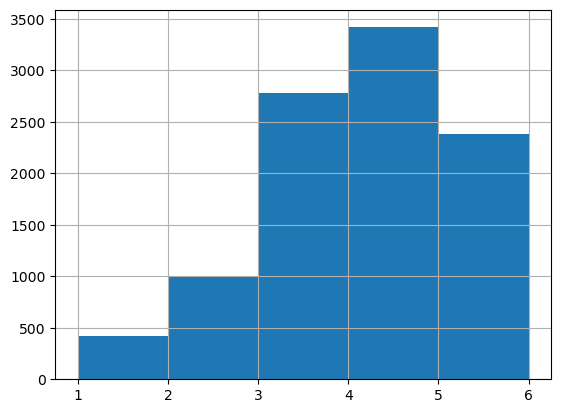

In [13]:
small_rat.Rating.hist(bins=[1,2,3,4,5,6])

In [14]:
small_rat.Rating.describe()

count    10000.000000
mean         3.633900
std          1.077213
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: Rating, dtype: float64

#### 1.2 NUmber of movies and users

In [15]:
max_Movie_Id = small_rat.MovieID.max()
print("Max ID of movies in the small ratings sample: " + str(max_Movie_Id))

Max ID of movies in the small ratings sample: 3952


In [16]:
count_Movie_Id = small_rat.MovieID.nunique()
print("Number of Movie ID in the small ratings sample: " + str(count_Movie_Id))

Number of Movie ID in the small ratings sample: 2159


#### 1.3 Number of ratings per movie

In [17]:
nb_ratings_per_movie = small_rat[["MovieID", "UserID"]].groupby(by = "MovieID").count()

In [18]:
nb_ratings_per_movie.describe()

,UserID
count,2159.000000
mean,4.631774
std,5.024420
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,48.000000


array([[<Axes: title={'center': 'UserID'}>]], dtype=object)

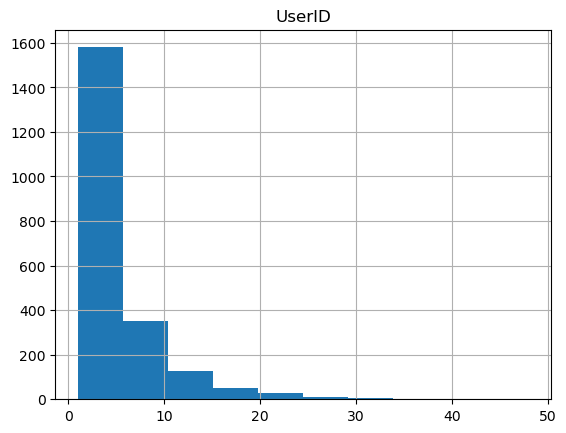

In [19]:
nb_ratings_per_movie.hist()

#### 1.4 Number of ratings per user

In [20]:
nb_ratings_per_user = small_rat[["MovieID", "UserID"]].groupby(by = "UserID").count()

In [21]:
nb_ratings_per_user.describe()

,MovieID
count,70.000000
mean,142.857143
std,145.350679
min,14.000000
25%,41.500000
50%,90.500000
75%,198.000000
max,684.000000


array([[<Axes: title={'center': 'MovieID'}>]], dtype=object)

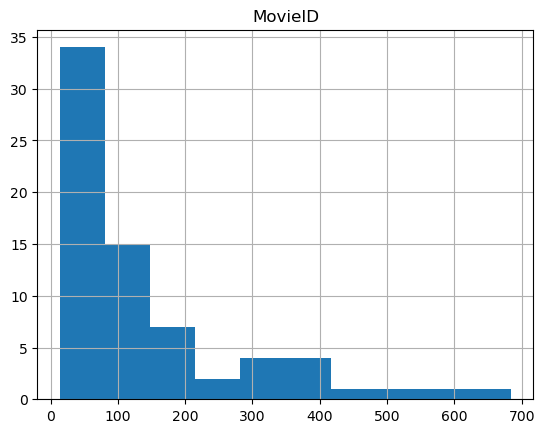

In [22]:
nb_ratings_per_user.hist()